# Real-Time PPO Inference

`ppo_v4.zip`를 다시 학습하지 않고 그대로 사용해서, `Day-ahead_result`의 일 단위 스케줄을 `pred_1_step` 기반으로 시간별 보정합니다.

핵심 포인트:
- 입력: `ESS_Scheduling/Day-ahead_result/load_*_schedule.csv` + `ESS_Scheduling/data/load_*.csv`
- 모델: `ESS_Scheduling/ppo_v4.zip`
- 오차 통계: `0%`에서 시작해서 `season_slot`별로 시간 흐름에 따라 누적 업데이트
- 용량: 각 시설의 day-ahead 결과 파일에 저장된 `capacity`를 읽어서 환경 호출 시 그대로 적용
- 출력: `ESS_Scheduling/Real-time_result`

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO

BASE_DIR = Path('/home/teedlab/Taehyun/CAPSTONE/ESS_Scheduling')
DAY_AHEAD_DIR = BASE_DIR / 'Day-ahead_result'
RAW_DATA_DIR = BASE_DIR / 'data'
MODEL_PATH = BASE_DIR / 'ppo_v4.zip'
OUTPUT_DIR = BASE_DIR / 'Real-time_result'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_RATE = 10.0
SOC_MIN = 0.1
SOC_MAX = 0.9
DELTA_T = 1.0
EFF_CH = 0.95
EFF_DIS = 0.95
LAMBDA_PEAK_BASE = 164.1
PEAK_DURATION_FACTOR = 6.0
LAMBDA_TRACK = 100.0
LAMBDA_SOC = 10000.0
LAMBDA_SELL = 10000.0
REWARD_SCALE = 1e-3
DELTA_LIMIT_RATIO = 0.1
INITIAL_SOC = 0.5
CARRY_SOC_BETWEEN_DAYS = False
DETERMINISTIC = True

TEST_FACILITY_ID = 1
BATCH_FACILITY_IDS = None  # 예: [1, 22, 26]
BATCH_LIMIT = None         # 예: 10

VIS_FACILITY_ID = 1
VIS_DATE = None           # 예: '2013-01-02'

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
plt.style.use('default')

In [2]:
def extract_facility_id(path):
    match = re.search(r'load_(\d+)_schedule\.csv$', Path(path).name)
    if not match:
        raise ValueError(f'could not parse facility id from {path}')
    return int(match.group(1))

def list_day_ahead_schedule_files(day_ahead_dir=DAY_AHEAD_DIR):
    paths = sorted(day_ahead_dir.glob('load_*_schedule.csv'), key=extract_facility_id)
    return paths

def init_error_history(season_slots):
    unique_slots = sorted(pd.Series(season_slots).dropna().unique())
    return {slot: [] for slot in unique_slots}

def get_error_stats(error_history, min_std=0.0):
    stats = {}
    for slot, values in error_history.items():
        if len(values) == 0:
            stats[slot] = (0.0, 0.0)
        elif len(values) == 1:
            stats[slot] = (float(values[0]), 0.0)
        else:
            mean_err = float(np.mean(values))
            std_err = float(max(np.std(values, ddof=1), min_std))
            stats[slot] = (mean_err, std_err)
    return stats

def abs_pct_error(actual, forecast, eps=1e-6):
    denom = max(abs(float(forecast)), eps)
    return abs(float(actual) - float(forecast)) / denom * 100.0

def wear_out_cost(delta_soc, capacity_kwh, price_per_kwh=150000.0, a=694.0, b=0.795, mu=0.95):
    total_price = capacity_kwh * price_per_kwh
    return float((total_price / (2 * capacity_kwh * (mu ** 2))) * ((b * (1 - delta_soc) ** (b - 1)) / a))

def prepare_real_time_input(facility_id, day_ahead_dir=DAY_AHEAD_DIR, raw_data_dir=RAW_DATA_DIR):
    schedule_path = day_ahead_dir / f'load_{facility_id}_schedule.csv'
    raw_path = raw_data_dir / f'load_{facility_id}.csv'
    if not schedule_path.exists():
        raise FileNotFoundError(schedule_path)
    if not raw_path.exists():
        raise FileNotFoundError(raw_path)

    schedule_df = pd.read_csv(schedule_path, parse_dates=['timestamp'])
    raw_df = pd.read_csv(raw_path, parse_dates=['timestamp'])

    merge_cols = ['timestamp', 'pred_1_step']
    merged = schedule_df.merge(
        raw_df[merge_cols],
        on='timestamp',
        how='left',
        validate='one_to_one',
    )
    if merged['pred_1_step'].isna().any():
        missing = int(merged['pred_1_step'].isna().sum())
        raise ValueError(f'facility {facility_id}: missing pred_1_step rows after merge ({missing})')

    merged = merged.sort_values('timestamp').reset_index(drop=True).copy()
    merged['facility_id'] = facility_id
    merged['date'] = merged['timestamp'].dt.date
    merged['x_da'] = merged['x'].astype(float)
    merged['schedule_da'] = merged['schedule'].astype(float)
    merged['result_da'] = merged['result'].astype(float)
    merged['real'] = merged['real'].astype(float)
    merged['pred_24_step'] = merged['pred_24_step'].astype(float)
    merged['pred_1_step'] = merged['pred_1_step'].astype(float)
    merged['price'] = merged['price'].astype(float)
    merged['capacity_kwh'] = merged['capacity'].astype(float)
    return merged, schedule_path, raw_path

available_schedule_files = list_day_ahead_schedule_files()
available_facility_ids = [extract_facility_id(path) for path in available_schedule_files]
pd.Series({
    'schedule_files': len(available_schedule_files),
    'first_facility_id': available_facility_ids[0] if available_facility_ids else None,
    'last_facility_id': available_facility_ids[-1] if available_facility_ids else None,
    'model_exists': MODEL_PATH.exists(),
})

schedule_files        733
first_facility_id       1
last_facility_id      763
model_exists         True
dtype: object

In [3]:
class ESSRealTimePPOEnv(gym.Env):
    metadata = {'render_modes': []}

    def __init__(
        self,
        df: pd.DataFrame,
        *,
        capacity_kwh: float,
        max_rate: float = MAX_RATE,
        soc_min: float = SOC_MIN,
        soc_max: float = SOC_MAX,
        delta_t: float = DELTA_T,
        eff_ch: float = EFF_CH,
        eff_dis: float = EFF_DIS,
        lambda_peak_base: float = LAMBDA_PEAK_BASE,
        peak_duration_factor: float = PEAK_DURATION_FACTOR,
        lambda_track: float = LAMBDA_TRACK,
        lambda_soc: float = LAMBDA_SOC,
        lambda_sell: float = LAMBDA_SELL,
        reward_scale: float = REWARD_SCALE,
        delta_limit_ratio: float = DELTA_LIMIT_RATIO,
        initial_soc: float = INITIAL_SOC,
        error_history: dict | None = None,
    ):
        super().__init__()
        self.df = df.reset_index(drop=True).copy()
        self.total_len = len(self.df)
        self.capacity_kwh = float(capacity_kwh)
        self.max_rate = float(max_rate)
        self.soc_min = float(soc_min)
        self.soc_max = float(soc_max)
        self.delta_t = float(delta_t)
        self.eff_ch = float(eff_ch)
        self.eff_dis = float(eff_dis)
        self.peak_cost_unit = float(lambda_peak_base * peak_duration_factor)
        self.lambda_track = float(lambda_track)
        self.lambda_soc = float(lambda_soc)
        self.lambda_sell = float(lambda_sell)
        self.reward_scale = float(reward_scale)
        self.delta_limit_ratio = float(delta_limit_ratio)
        self.initial_soc = float(initial_soc)
        self.error_history = error_history if error_history is not None else init_error_history(self.df['season_slot'])

        self.data_real = self.df['real'].to_numpy(np.float32)
        self.data_price = self.df['price'].to_numpy(np.float32)
        self.data_x_da = self.df['x_da'].to_numpy(np.float32)
        self.data_pred_1h = self.df['pred_1_step'].to_numpy(np.float32)
        self.data_pred_24h = self.df['pred_24_step'].to_numpy(np.float32)
        self.data_schedule_da = self.df['schedule_da'].to_numpy(np.float32)
        self.data_result_da = self.df['result_da'].to_numpy(np.float32)
        self.data_season_slot = self.df['season_slot'].astype(str).to_numpy()

        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)
        self.obs_dim = 13
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.obs_dim,), dtype=np.float32)

        self.t = 0
        self.soc = self.initial_soc
        self.peak_so_far = 0.0
        self.corrected_history = []

    def current_error_stats(self, season_slot):
        return get_error_stats(self.error_history).get(season_slot, (0.0, 0.0))

    def _history_features(self):
        if not self.corrected_history:
            return 0.0, 0.0, 0.0
        hist = np.asarray(self.corrected_history, dtype=float)
        last_opt = float(hist[-1])
        past_mean = float(hist.mean())
        past_max = float(hist.max())
        return last_opt, past_mean, past_max

    def _future_schedule_features(self, curr_idx):
        future_slice = self.data_schedule_da[curr_idx + 1 :]
        if len(future_slice) == 0:
            return 0.0, 0.0
        return float(np.mean(future_slice)), float(np.max(future_slice))

    def _get_obs(self):
        curr_idx = min(self.t, self.total_len - 1)
        season_slot = self.data_season_slot[curr_idx]
        err_mean, err_std = self.current_error_stats(season_slot)
        last_opt, past_mean, past_max = self._history_features()
        future_mean, future_max = self._future_schedule_features(curr_idx)
        x_da = float(self.data_x_da[curr_idx])
        raw_pred = float(self.data_pred_1h[curr_idx])
        price = float(self.data_price[curr_idx])
        t_norm = float(curr_idx / max(self.total_len - 1, 1))

        obs = np.array([
            t_norm,
            float(self.soc),
            price,
            x_da,
            last_opt,
            past_mean,
            past_max,
            raw_pred,
            future_mean,
            future_max,
            float(self.peak_so_far),
            float(err_mean),
            float(err_std),
        ], dtype=np.float32)
        return obs

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t = 0
        self.soc = float(self.initial_soc)
        self.peak_so_far = 0.0
        self.corrected_history = []
        return self._get_obs(), {}

    def step(self, action):
        curr_idx = min(self.t, self.total_len - 1)
        row = self.df.iloc[curr_idx]

        x_da = float(self.data_x_da[curr_idx])
        raw_action = float(np.array(action).ravel()[0])
        delta_limit = self.delta_limit_ratio * abs(x_da)
        delta_x = raw_action * delta_limit
        x_rt = float(np.clip(x_da + delta_x, -0.95, 0.95))
        ess_adjustment_kw = x_rt * self.max_rate

        real_load = float(self.data_real[curr_idx])
        pred_1h = float(self.data_pred_1h[curr_idx])
        price = float(self.data_price[curr_idx])
        rt_schedule_1h = float(pred_1h + ess_adjustment_kw)
        rt_result = float(real_load + ess_adjustment_kw)

        if ess_adjustment_kw >= 0:
            delta_soc = (ess_adjustment_kw * self.delta_t * self.eff_ch) / self.capacity_kwh
        else:
            delta_soc = (ess_adjustment_kw * self.delta_t / self.eff_dis) / self.capacity_kwh
        next_soc = float(self.soc + delta_soc)

        energy_cost = rt_result * price * self.delta_t
        new_peak = max(self.peak_so_far, rt_result)
        peak_cost_step = 0.0
        if new_peak > self.peak_so_far and new_peak > 0:
            peak_cost_step = (new_peak - self.peak_so_far) * self.peak_cost_unit
        self.peak_so_far = float(new_peak)

        track_penalty = abs(delta_x) * self.lambda_track
        soc_penalty = 0.0
        if next_soc < self.soc_min or next_soc > self.soc_max:
            soc_penalty = self.lambda_soc + abs(next_soc - 0.5) * 1000.0
            next_soc = float(np.clip(next_soc, self.soc_min, self.soc_max))

        sell_penalty = 0.0
        if rt_result < 0:
            sell_penalty = abs(rt_result) * self.lambda_sell

        deg_cost = wear_out_cost(abs(delta_soc), self.capacity_kwh)
        total_cost_raw = energy_cost + peak_cost_step + track_penalty + soc_penalty + sell_penalty + deg_cost
        reward = -total_cost_raw * self.reward_scale

        season_slot = self.data_season_slot[curr_idx]
        err_mean_before, err_std_before = self.current_error_stats(season_slot)
        step_abs_pct_error = abs_pct_error(real_load, pred_1h)
        self.error_history.setdefault(season_slot, []).append(step_abs_pct_error)
        err_mean_after, err_std_after = self.current_error_stats(season_slot)

        self.corrected_history.append(rt_result)
        self.soc = next_soc
        self.t += 1

        terminated = self.t >= self.total_len
        truncated = False
        next_obs = self._get_obs() if not terminated else np.zeros(self.obs_dim, dtype=np.float32)

        info = {
            'timestamp': row['timestamp'],
            'date': row['date'],
            'facility_id': int(row['facility_id']),
            'season': row['season'],
            'slot': row['slot'],
            'season_slot': season_slot,
            'capacity_kWh': float(self.capacity_kwh),
            'max_rate_kW': float(self.max_rate),
            'real': real_load,
            'pred_1_step': pred_1h,
            'pred_24_step': float(self.data_pred_24h[curr_idx]),
            'price': price,
            'x_da': x_da,
            'x_rt': x_rt,
            'delta_x': float(delta_x),
            'delta_limit': float(delta_limit),
            'ess_adjustment_kW': float(ess_adjustment_kw),
            'soc': float(self.soc),
            'adaptive_error_mean_pct': float(err_mean_before),
            'adaptive_error_std_pct': float(err_std_before),
            'updated_error_mean_pct': float(err_mean_after),
            'updated_error_std_pct': float(err_std_after),
            'abs_pct_error_1h': float(step_abs_pct_error),
            'day_ahead_schedule': float(self.data_schedule_da[curr_idx]),
            'day_ahead_result': float(self.data_result_da[curr_idx]),
            'rt_schedule_1h': float(rt_schedule_1h),
            'rt_result': float(rt_result),
            'peak_so_far': float(self.peak_so_far),
            'reward': float(reward),
        }
        return next_obs, reward, terminated, truncated, info

In [4]:
def run_real_time_correction_for_facility(
    facility_id,
    model,
    *,
    day_ahead_dir=DAY_AHEAD_DIR,
    raw_data_dir=RAW_DATA_DIR,
    max_rate=MAX_RATE,
    soc_min=SOC_MIN,
    soc_max=SOC_MAX,
    initial_soc=INITIAL_SOC,
    carry_soc_between_days=CARRY_SOC_BETWEEN_DAYS,
    deterministic=DETERMINISTIC,
):
    full_df, schedule_path, raw_path = prepare_real_time_input(
        facility_id,
        day_ahead_dir=day_ahead_dir,
        raw_data_dir=raw_data_dir,
    )
    capacity_kwh = float(full_df['capacity_kwh'].iloc[0])
    error_history = init_error_history(full_df['season_slot'])
    day_frames = []
    day_logs = []
    next_initial_soc = float(initial_soc)
    running_peak_rt = 0.0
    running_peak_da = 0.0

    grouped_days = list(full_df.groupby(full_df['timestamp'].dt.date, sort=True))
    for day_idx, (date_key, day_df) in enumerate(grouped_days):
        day_df = day_df.reset_index(drop=True).copy()
        before_stats = get_error_stats(error_history)
        day_error_before = [before_stats.get(slot, (0.0, 0.0))[0] for slot in day_df['season_slot']]

        env = ESSRealTimePPOEnv(
            day_df,
            capacity_kwh=capacity_kwh,
            max_rate=max_rate,
            soc_min=soc_min,
            soc_max=soc_max,
            initial_soc=next_initial_soc,
            error_history=error_history,
        )
        obs, _ = env.reset()
        done = False
        hourly_records = []
        while not done:
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, reward, terminated, truncated, info = env.step(action)
            hourly_records.append(info)
            done = terminated or truncated

        error_history = env.error_history
        if carry_soc_between_days:
            next_initial_soc = float(env.soc)
        else:
            next_initial_soc = float(initial_soc)

        day_result_df = pd.DataFrame(hourly_records)
        day_result_df['day_idx'] = day_idx
        day_frames.append(day_result_df)

        after_stats = get_error_stats(error_history)
        day_error_after = [after_stats.get(slot, (0.0, 0.0))[0] for slot in day_df['season_slot']]

        running_peak_rt = max(running_peak_rt, float(day_result_df['rt_result'].max()))
        running_peak_da = max(running_peak_da, float(day_result_df['day_ahead_result'].max()))

        day_logs.append({
            'facility_id': facility_id,
            'day_idx': day_idx,
            'date': pd.Timestamp(date_key),
            'rows': len(day_df),
            'capacity_kWh': capacity_kwh,
            'start_soc': float(hourly_records[0]['soc'] - (hourly_records[0]['ess_adjustment_kW'] * EFF_CH / capacity_kwh if hourly_records[0]['ess_adjustment_kW'] >= 0 else hourly_records[0]['ess_adjustment_kW'] / EFF_DIS / capacity_kwh)),
            'end_soc': float(day_result_df['soc'].iloc[-1]),
            'forecast_1h_mean_kW': float(day_result_df['pred_1_step'].mean()),
            'forecast_24h_mean_kW': float(day_result_df['pred_24_step'].mean()),
            'actual_mean_kW': float(day_result_df['real'].mean()),
            'mean_error_pct_before_update': float(np.mean(day_error_before)) if day_error_before else 0.0,
            'mean_error_pct_after_update': float(np.mean(day_error_after)) if day_error_after else 0.0,
            'avg_abs_pct_error_1h': float(day_result_df['abs_pct_error_1h'].mean()),
            'day_ahead_peak_kW': float(day_result_df['day_ahead_result'].max()),
            'rt_peak_kW': float(day_result_df['rt_result'].max()),
            'peak_so_far_rt_kW': float(running_peak_rt),
        })

    result_df = pd.concat(day_frames, ignore_index=True) if day_frames else pd.DataFrame()
    day_summary_df = pd.DataFrame(day_logs)

    metadata = {
        'facility_id': facility_id,
        'rows': int(len(full_df)),
        'days': int(len(day_logs)),
        'capacity_kWh': capacity_kwh,
        'max_rate_kW': float(max_rate),
        'avg_abs_pct_error_1h': float(result_df['abs_pct_error_1h'].mean()) if not result_df.empty else 0.0,
        'day_ahead_peak_kW': float(running_peak_da),
        'rt_peak_kW': float(running_peak_rt),
        'peak_delta_kW': float(running_peak_rt - running_peak_da),
        'day_ahead_energy_cost': float((result_df['day_ahead_result'] * result_df['price']).sum()) if not result_df.empty else 0.0,
        'rt_energy_cost': float((result_df['rt_result'] * result_df['price']).sum()) if not result_df.empty else 0.0,
        'final_soc': float(result_df['soc'].iloc[-1]) if not result_df.empty else float(initial_soc),
        'schedule_path': str(schedule_path),
        'raw_path': str(raw_path),
    }
    return result_df, day_summary_df, metadata

model = PPO.load(str(MODEL_PATH))
test_result_df, test_day_summary_df, test_metadata = run_real_time_correction_for_facility(TEST_FACILITY_ID, model)
pd.Series(test_metadata)

facility_id                                                              1
rows                                                                 11784
days                                                                   491
capacity_kWh                                                        4480.0
max_rate_kW                                                           10.0
avg_abs_pct_error_1h                                              2.486771
day_ahead_peak_kW                                               200.605408
rt_peak_kW                                                      200.623349
peak_delta_kW                                                     0.017941
day_ahead_energy_cost                                     213792938.139759
rt_energy_cost                                            213820565.582859
final_soc                                                         0.498502
schedule_path            /home/teedlab/Taehyun/CAPSTONE/ESS_Scheduling/...
raw_path                 

In [5]:
test_result_path = OUTPUT_DIR / f'load_{TEST_FACILITY_ID}_rt_schedule.csv'
test_day_summary_path = OUTPUT_DIR / f'load_{TEST_FACILITY_ID}_rt_day_summary.csv'
test_result_df.to_csv(test_result_path, index=False)
test_day_summary_df.to_csv(test_day_summary_path, index=False)

display(test_result_df.head())
display(test_day_summary_df.head())
pd.Series({
    'saved_result': str(test_result_path),
    'saved_day_summary': str(test_day_summary_path),
    'rows': len(test_result_df),
    'days': len(test_day_summary_df),
})

,timestamp,date,facility_id,season,slot,season_slot,capacity_kWh,max_rate_kW,real,pred_1_step,pred_24_step,price,x_da,x_rt,delta_x,delta_limit,ess_adjustment_kW,soc,adaptive_error_mean_pct,adaptive_error_std_pct,updated_error_mean_pct,updated_error_std_pct,abs_pct_error_1h,day_ahead_schedule,day_ahead_result,rt_schedule_1h,rt_result,peak_so_far,reward,day_idx
0,2013-01-02 00:00:00,2013-01-02,1,winter,low,winter/low,4480.0,10.0,175.574005,173.809967,175.143066,112.199997,-0.135975,-0.135598,0.000377,0.013598,-1.355983,0.499681,0.000000,0.000000,1.014923,0.000000,1.014923,173.78331,174.214249,172.453984,174.218022,174.218022,-191.177567,0
1,2013-01-02 01:00:00,2013-01-02,1,winter,low,winter/low,4480.0,10.0,176.792007,178.153473,178.362946,112.199997,-0.457963,-0.456405,0.001558,0.045796,-4.564054,0.498609,1.014923,0.000000,0.889566,0.177282,0.764209,173.78331,172.212372,173.589419,172.227953,174.218022,-19.419349,0
2,2013-01-02 02:00:00,2013-01-02,1,winter,low,winter/low,4480.0,10.0,178.065994,178.277328,181.199478,112.199997,-0.741617,-0.739133,0.002484,0.074162,-7.391329,0.496872,0.889566,0.177282,0.632558,0.462465,0.118542,173.78331,170.649826,170.885999,170.674665,174.218022,-19.245176,0
3,2013-01-02 03:00:00,2013-01-02,1,winter,low,winter/low,4480.0,10.0,185.388000,180.702637,183.151993,112.199997,-0.936869,-0.933828,0.003041,0.093687,-9.338279,0.494678,0.632558,0.462465,1.122633,1.050370,2.592859,173.78331,176.019302,171.364358,176.049722,176.049722,-21.651813,0
4,2013-01-02 04:00:00,2013-01-02,1,winter,low,winter/low,4480.0,10.0,186.466003,181.807343,183.283310,112.199997,-0.950000,-0.946949,0.003051,0.095000,-9.469489,0.492453,1.122633,1.050370,1.410590,1.114474,2.562416,173.78331,176.966003,172.337854,176.996515,176.996515,-20.886766,0


,facility_id,day_idx,date,rows,capacity_kWh,start_soc,end_soc,forecast_1h_mean_kW,forecast_24h_mean_kW,actual_mean_kW,mean_error_pct_before_update,mean_error_pct_after_update,avg_abs_pct_error_1h,day_ahead_peak_kW,rt_peak_kW,peak_so_far_rt_kW
0,1,0,2013-01-02,24,4480.0,0.5,0.498075,145.240008,145.137215,145.259916,0.000000,1.430417,1.430417,176.966003,176.996515,176.996515
1,1,1,2013-01-03,24,4480.0,0.5,0.498053,143.679705,145.581840,142.956334,1.430417,2.006886,2.583354,180.307541,180.317364,180.317364
2,1,2,2013-01-04,24,4480.0,0.5,0.497969,149.822194,144.208751,149.391667,2.006886,2.567219,3.687885,183.289139,183.298074,183.298074
3,1,3,2013-01-07,24,4480.0,0.5,0.498285,160.498717,144.905017,166.749917,2.567219,3.165421,4.960027,190.198410,190.226985,190.226985
4,1,4,2013-01-08,24,4480.0,0.5,0.498606,147.592592,158.418816,146.461584,3.165421,2.884625,1.761439,182.532547,182.537615,190.226985


saved_result         /home/teedlab/Taehyun/CAPSTONE/ESS_Scheduling/...
saved_day_summary    /home/teedlab/Taehyun/CAPSTONE/ESS_Scheduling/...
rows                                                             11784
days                                                               491
dtype: object

In [6]:
target_schedule_files = list_day_ahead_schedule_files()
if BATCH_FACILITY_IDS is not None:
    wanted = set(BATCH_FACILITY_IDS)
    target_schedule_files = [path for path in target_schedule_files if extract_facility_id(path) in wanted]
if BATCH_LIMIT is not None:
    target_schedule_files = target_schedule_files[:BATCH_LIMIT]

batch_summaries = []
batch_failures = []

for schedule_path in target_schedule_files:
    facility_id = extract_facility_id(schedule_path)
    try:
        facility_result_df, facility_day_summary_df, facility_metadata = run_real_time_correction_for_facility(
            facility_id,
            model,
        )
        facility_result_df.to_csv(OUTPUT_DIR / f'load_{facility_id}_rt_schedule.csv', index=False)
        facility_day_summary_df.to_csv(OUTPUT_DIR / f'load_{facility_id}_rt_day_summary.csv', index=False)
        batch_summaries.append(facility_metadata)
        print(f'processed facility {facility_id}: rows={facility_metadata["rows"]}, days={facility_metadata["days"]}')
    except Exception as exc:
        batch_failures.append({
            'facility_id': facility_id,
            'schedule_path': str(schedule_path),
            'error': str(exc),
        })
        print(f'failed facility {facility_id}: {exc}')

batch_summary_df = pd.DataFrame(batch_summaries).sort_values('facility_id').reset_index(drop=True) if batch_summaries else pd.DataFrame()
batch_failures_df = pd.DataFrame(batch_failures).sort_values('facility_id').reset_index(drop=True) if batch_failures else pd.DataFrame(columns=['facility_id', 'schedule_path', 'error'])

batch_summary_path = OUTPUT_DIR / '_batch_summary.csv'
batch_failures_path = OUTPUT_DIR / '_batch_failures.csv'
batch_summary_df.to_csv(batch_summary_path, index=False)
batch_failures_df.to_csv(batch_failures_path, index=False)

pd.Series({
    'processed_facilities': int(len(batch_summary_df)),
    'failed_facilities': int(len(batch_failures_df)),
    'batch_summary_path': str(batch_summary_path),
    'batch_failures_path': str(batch_failures_path),
})

processed facility 1: rows=11784, days=491
processed facility 2: rows=11448, days=477
processed facility 3: rows=11904, days=496
processed facility 4: rows=11688, days=487
processed facility 5: rows=11904, days=496
processed facility 6: rows=11448, days=477
processed facility 7: rows=11640, days=485
processed facility 8: rows=11928, days=497
processed facility 9: rows=11880, days=495
processed facility 10: rows=11256, days=469
processed facility 11: rows=11904, days=496
processed facility 12: rows=11904, days=496
processed facility 13: rows=11856, days=494
processed facility 14: rows=11904, days=496
processed facility 15: rows=11904, days=496
processed facility 16: rows=11904, days=496
processed facility 17: rows=11520, days=480
processed facility 18: rows=11856, days=494
processed facility 19: rows=11640, days=485
processed facility 20: rows=11856, days=494
processed facility 21: rows=11856, days=494
processed facility 22: rows=11904, days=496
processed facility 23: rows=11904, days=4

processed_facilities                                                  733
failed_facilities                                                       0
batch_summary_path      /home/teedlab/Taehyun/CAPSTONE/ESS_Scheduling/...
batch_failures_path     /home/teedlab/Taehyun/CAPSTONE/ESS_Scheduling/...
dtype: object

In [7]:
if not batch_summary_df.empty:
    display(batch_summary_df.head())
if not batch_failures_df.empty:
    display(batch_failures_df.head())

,facility_id,rows,days,capacity_kWh,max_rate_kW,avg_abs_pct_error_1h,day_ahead_peak_kW,rt_peak_kW,peak_delta_kW,day_ahead_energy_cost,rt_energy_cost,final_soc,schedule_path,raw_path
0,1,11784,491,4480.0,10.0,2.486771,200.605408,200.623349,0.017941,2.137929e+08,2.138206e+08,0.498502,/home/teedlab/Taehyun/CAPSTONE/ESS_Scheduling/...,/home/teedlab/Taehyun/CAPSTONE/ESS_Scheduling/...
1,2,11448,477,10.0,10.0,8.040921,0.981739,0.985365,0.003626,5.008525e+05,5.036337e+05,0.474816,/home/teedlab/Taehyun/CAPSTONE/ESS_Scheduling/...,/home/teedlab/Taehyun/CAPSTONE/ESS_Scheduling/...
2,3,11904,496,10.0,10.0,16.636379,0.550210,0.552171,0.001961,1.811343e+05,1.824121e+05,0.482853,/home/teedlab/Taehyun/CAPSTONE/ESS_Scheduling/...,/home/teedlab/Taehyun/CAPSTONE/ESS_Scheduling/...
3,4,11688,487,10.0,10.0,2.297743,0.598682,0.601621,0.002939,4.076555e+05,4.102609e+05,0.479355,/home/teedlab/Taehyun/CAPSTONE/ESS_Scheduling/...,/home/teedlab/Taehyun/CAPSTONE/ESS_Scheduling/...
4,5,11904,496,120.0,10.0,3.095209,7.702503,7.722869,0.020366,4.314935e+06,4.331985e+06,0.492692,/home/teedlab/Taehyun/CAPSTONE/ESS_Scheduling/...,/home/teedlab/Taehyun/CAPSTONE/ESS_Scheduling/...


facility_id                                   26
rows_in_file                               11856
rows_plotted                                  24
start                        2013-01-02 00:00:00
end                          2013-01-02 23:00:00
capacity_kWh                                40.0
max_rate_kW                                 10.0
avg_abs_pct_error_1h                    3.582152
max_abs_ess_adjustment_kW               1.149019
dtype: object

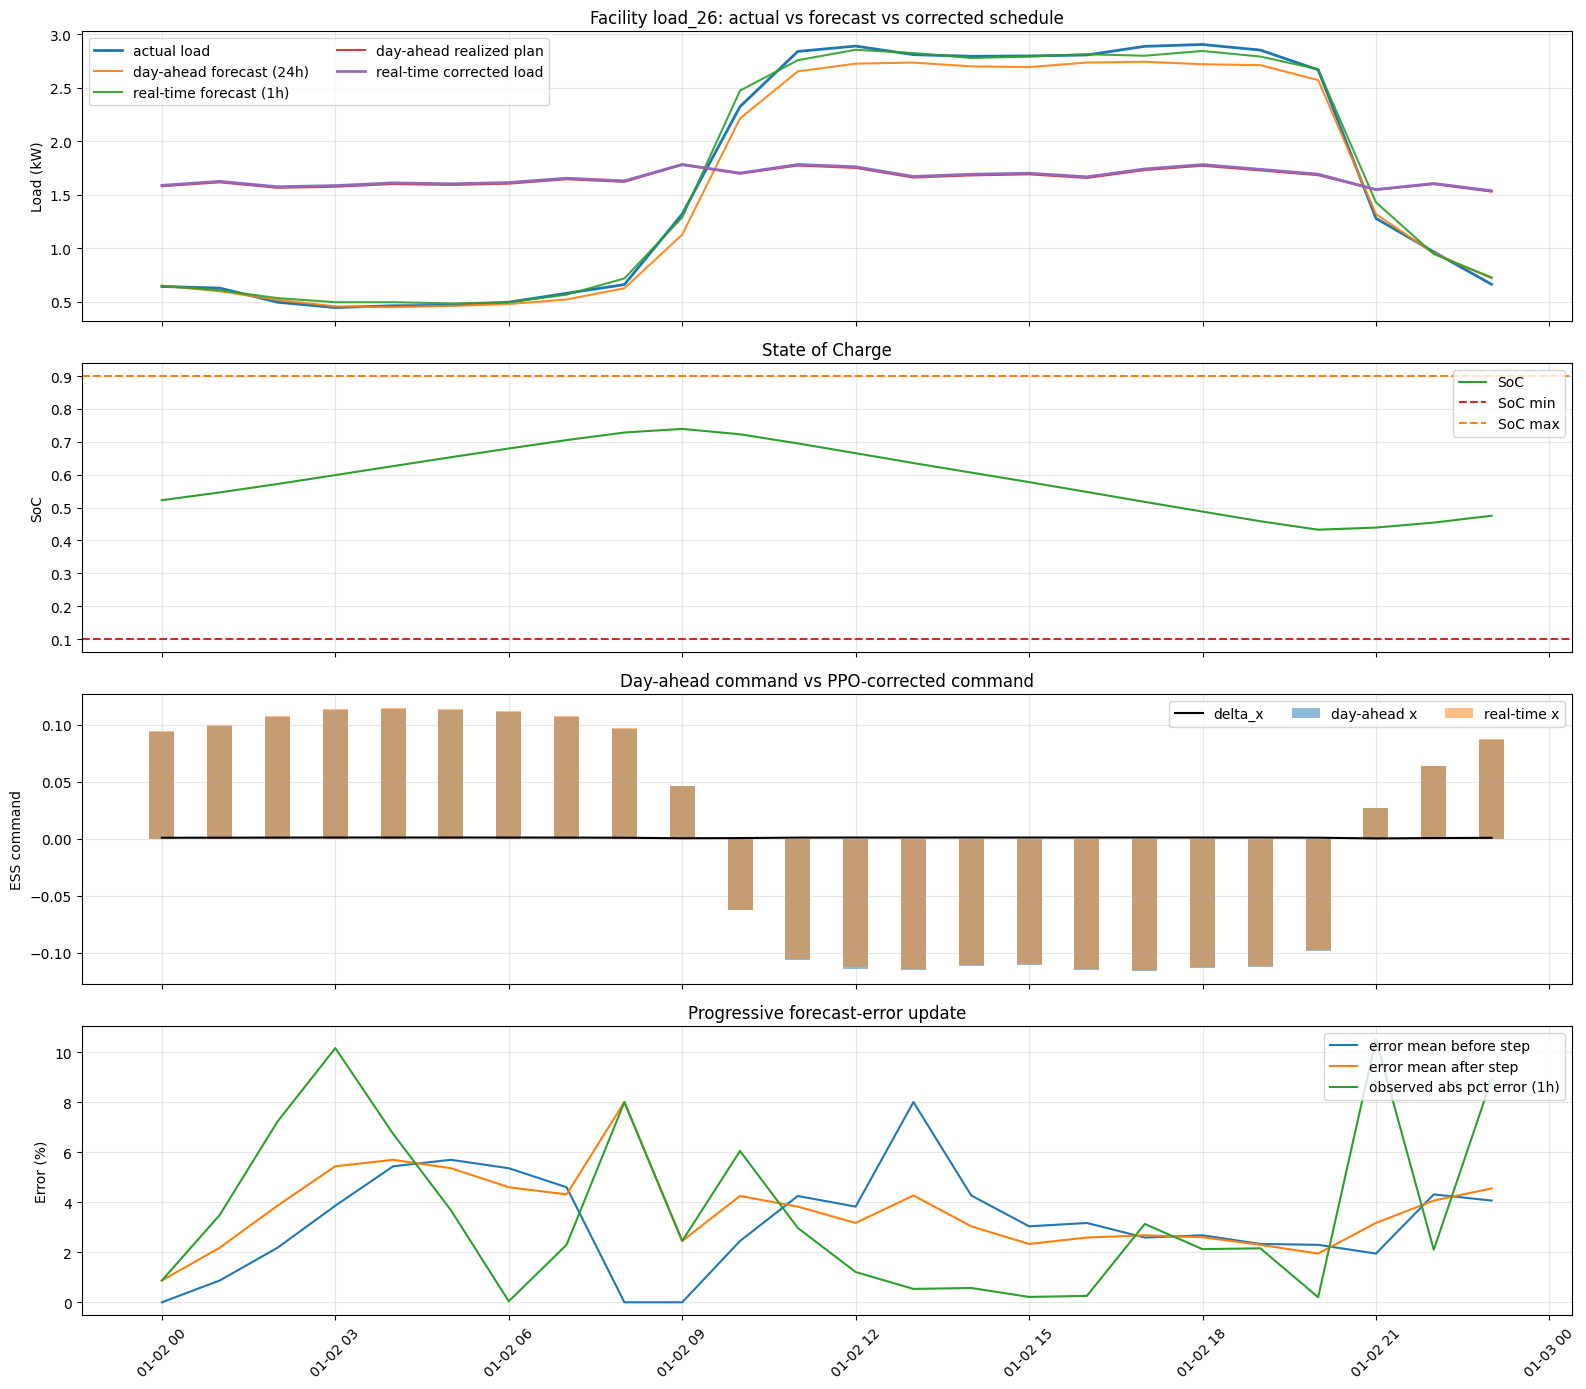

In [11]:
VIS_FACILITY_ID = 26

vis_path = OUTPUT_DIR / f'load_{VIS_FACILITY_ID}_rt_schedule.csv'
vis_df = pd.read_csv(vis_path, parse_dates=['timestamp', 'date'])
if VIS_DATE is None:
    vis_slice = vis_df.iloc[:24].copy()
else:
    vis_date = pd.Timestamp(VIS_DATE).date()
    vis_slice = vis_df.loc[vis_df['timestamp'].dt.date == vis_date].copy()
    if vis_slice.empty:
        raise ValueError(f'no rows found for VIS_DATE={VIS_DATE}')

display(pd.Series({
    'facility_id': VIS_FACILITY_ID,
    'rows_in_file': len(vis_df),
    'rows_plotted': len(vis_slice),
    'start': vis_slice['timestamp'].min(),
    'end': vis_slice['timestamp'].max(),
    'capacity_kWh': float(vis_slice['capacity_kWh'].iloc[0]),
    'max_rate_kW': float(vis_slice['max_rate_kW'].iloc[0]),
    'avg_abs_pct_error_1h': float(vis_slice['abs_pct_error_1h'].mean()),
    'max_abs_ess_adjustment_kW': float(vis_slice['ess_adjustment_kW'].abs().max()),
}))

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

axes[0].plot(vis_slice['timestamp'], vis_slice['real'], label='actual load', linewidth=2)
axes[0].plot(vis_slice['timestamp'], vis_slice['pred_24_step'], label='day-ahead forecast (24h)', alpha=0.9)
axes[0].plot(vis_slice['timestamp'], vis_slice['pred_1_step'], label='real-time forecast (1h)', alpha=0.9)
axes[0].plot(vis_slice['timestamp'], vis_slice['day_ahead_result'], label='day-ahead realized plan', alpha=0.9)
axes[0].plot(vis_slice['timestamp'], vis_slice['rt_result'], label='real-time corrected load', linewidth=2)
axes[0].set_ylabel('Load (kW)')
axes[0].set_title(f'Facility load_{VIS_FACILITY_ID}: actual vs forecast vs corrected schedule')
axes[0].legend(loc='upper left', ncol=2)
axes[0].grid(alpha=0.3)

axes[1].plot(vis_slice['timestamp'], vis_slice['soc'], label='SoC', color='tab:green')
axes[1].axhline(SOC_MIN, color='tab:red', linestyle='--', label='SoC min')
axes[1].axhline(SOC_MAX, color='tab:orange', linestyle='--', label='SoC max')
axes[1].set_ylabel('SoC')
axes[1].set_title('State of Charge')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

width = 0.018
axes[2].bar(vis_slice['timestamp'], vis_slice['x_da'], width=width, label='day-ahead x', alpha=0.5)
axes[2].bar(vis_slice['timestamp'], vis_slice['x_rt'], width=width, label='real-time x', alpha=0.5)
axes[2].plot(vis_slice['timestamp'], vis_slice['delta_x'], label='delta_x', color='black', linewidth=1.5)
axes[2].set_ylabel('ESS command')
axes[2].set_title('Day-ahead command vs PPO-corrected command')
axes[2].legend(loc='upper right', ncol=3)
axes[2].grid(alpha=0.3)

axes[3].plot(vis_slice['timestamp'], vis_slice['adaptive_error_mean_pct'], label='error mean before step', linewidth=1.5)
axes[3].plot(vis_slice['timestamp'], vis_slice['updated_error_mean_pct'], label='error mean after step', linewidth=1.5)
axes[3].plot(vis_slice['timestamp'], vis_slice['abs_pct_error_1h'], label='observed abs pct error (1h)', linewidth=1.5)
axes[3].set_ylabel('Error (%)')
axes[3].set_title('Progressive forecast-error update')
axes[3].legend(loc='upper right')
axes[3].grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()